# ICD10h Tree Structure Exploration

Visualize the hierarchy in the ICD10h masterlist to understand branching factors and tree shape before building the LLM-guided tree search.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import Counter, defaultdict
from pathlib import Path

DATA_PATH = Path("../data/ICD10h_Masterlist_2024.xlsx")
df = pd.read_excel(DATA_PATH, sheet_name="Masterlist", engine="openpyxl")
print(f"Rows: {len(df):,}")
df.head()

Rows: 14,088


,IDMasterlist,ICD10h,ICD10,icd10_2levelCATEGORY,ICD10_2levelCAUSE,ICD10h_DESCRIPTION,HistCat,DoNotUse,NotForUnderlying,GenderSpecific
0,1,A00.000,A00.0,Cholera,"Cholera due to Vibrio cholerae 01, biovar chol...","Cholera due to Vibrio cholerae 01, biovar chol...",Diarrhoea,0,0,0
1,2,A00.100,A00.1,Cholera,"Cholera due to Vibrio cholerae 01, biovar el tor","Cholera due to Vibrio cholerae 01, biovar el tor",Diarrhoea,0,0,0
2,3,A00.900,A00.9,Cholera,"Cholera, unspecified","Cholera, unspecified",Diarrhoea,0,0,0
3,4,A00.901,A00.9,Cholera,"Cholera, unspecified",Choleraic diarrhoea,Diarrhoea,0,0,0
4,5,A01.000,A01.0,Typhoid and paratyphoid fevers,Typhoid fever,Typhoid fever,Diarrhoea,0,0,0


## 1. Derive hierarchy levels from ICD10h codes

The code format is `X00.000` (letter + 2 digits + dot + 3 digits).  
Natural hierarchy levels:
- **Chapter**: first letter (A-Z) — 25 chapters
- **Block**: first 3 chars (e.g. A00) — maps 1:1 to `icd10_2levelCATEGORY`
- **Category**: chars before dot + first digit after (e.g. A00.0) — ICD10 level
- **Leaf**: full ICD10h code (e.g. A00.001)

In [2]:
df["chapter"] = df["ICD10h"].str[0]
df["block"] = df["ICD10h"].str[:3]          # e.g. A00
df["category"] = df["ICD10h"].str[:5]        # e.g. A00.0
df["leaf"] = df["ICD10h"]                    # e.g. A00.001

n_chapters = df["chapter"].nunique()
n_blocks = df["block"].nunique()
n_categories = df["category"].nunique()
n_leaves = df["leaf"].nunique()

print(f"Chapters:   {n_chapters:>6,}")
print(f"Blocks:     {n_blocks:>6,}")
print(f"Categories: {n_categories:>6,}")
print(f"Leaves:     {n_leaves:>6,}")

Chapters:       25
Blocks:      2,042
Categories: 10,555
Leaves:     14,088


## 2. Branching factor at each level

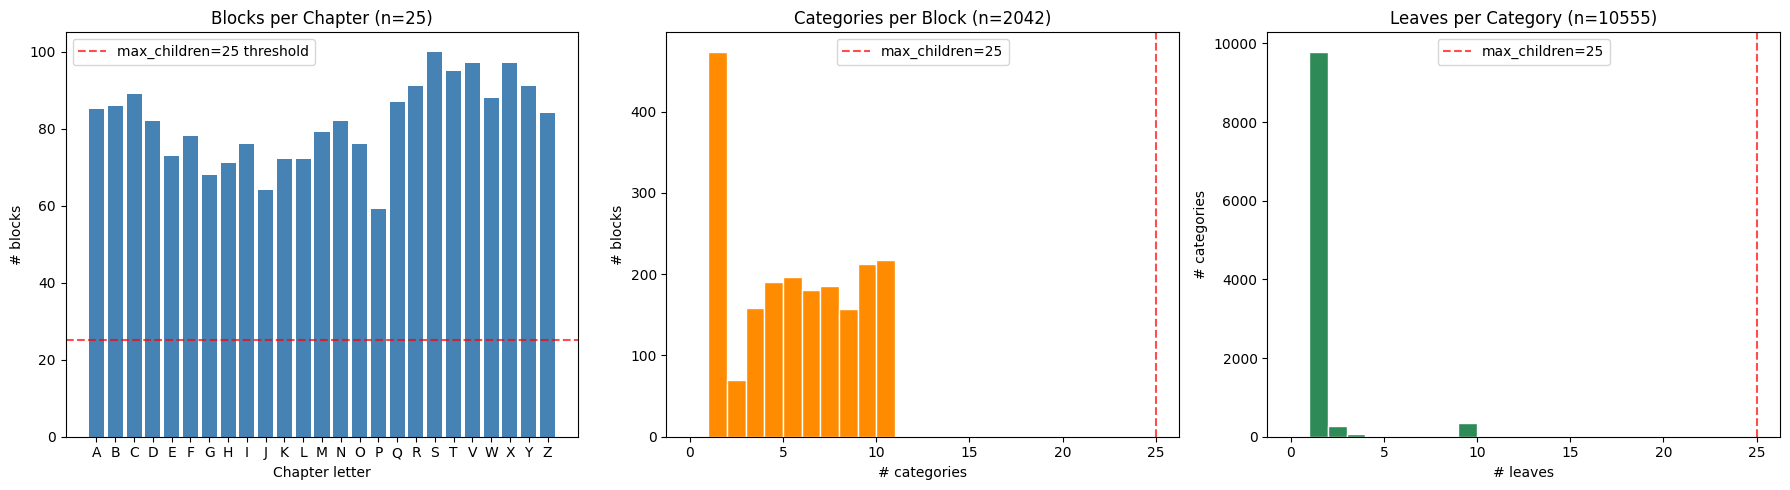


--- Branching factor stats ---
      Blocks/Chapter: mean=81.7  median=82  max=100  >25: 25
          Cats/Block: mean=5.2  median=5  max=10  >25: 0
          Leaves/Cat: mean=1.3  median=1  max=18  >25: 0


In [3]:
# Children per chapter (how many blocks per chapter letter)
blocks_per_chapter = df.groupby("chapter")["block"].nunique().sort_index()
# Children per block (how many categories per block)
cats_per_block = df.groupby("block")["category"].nunique()
# Children per category (how many leaves per category)
leaves_per_cat = df.groupby("category")["leaf"].nunique()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(blocks_per_chapter.index, blocks_per_chapter.values, color="steelblue")
axes[0].set_title(f"Blocks per Chapter (n={n_chapters})")
axes[0].set_xlabel("Chapter letter")
axes[0].set_ylabel("# blocks")
axes[0].axhline(25, color="red", ls="--", alpha=0.7, label="max_children=25 threshold")
axes[0].legend()

axes[1].hist(cats_per_block.values, bins=range(0, cats_per_block.max()+2), color="darkorange", edgecolor="white")
axes[1].set_title(f"Categories per Block (n={n_blocks})")
axes[1].set_xlabel("# categories")
axes[1].set_ylabel("# blocks")
axes[1].axvline(25, color="red", ls="--", alpha=0.7, label="max_children=25")
axes[1].legend()

axes[2].hist(leaves_per_cat.values, bins=range(0, min(leaves_per_cat.max()+2, 30)), color="seagreen", edgecolor="white")
axes[2].set_title(f"Leaves per Category (n={n_categories})")
axes[2].set_xlabel("# leaves")
axes[2].set_ylabel("# categories")
axes[2].axvline(25, color="red", ls="--", alpha=0.7, label="max_children=25")
axes[2].legend()

plt.tight_layout()
plt.show()

print("\n--- Branching factor stats ---")
for name, series in [("Blocks/Chapter", blocks_per_chapter), ("Cats/Block", cats_per_block), ("Leaves/Cat", leaves_per_cat)]:
    print(f"{name:>20s}: mean={series.mean():.1f}  median={series.median():.0f}  max={series.max()}  >25: {(series>25).sum()}")

## 3. HistCat as a potential grouping level

The masterlist has a `HistCat` column (19 unique values) that could serve as a coarser top-level grouping above chapters.

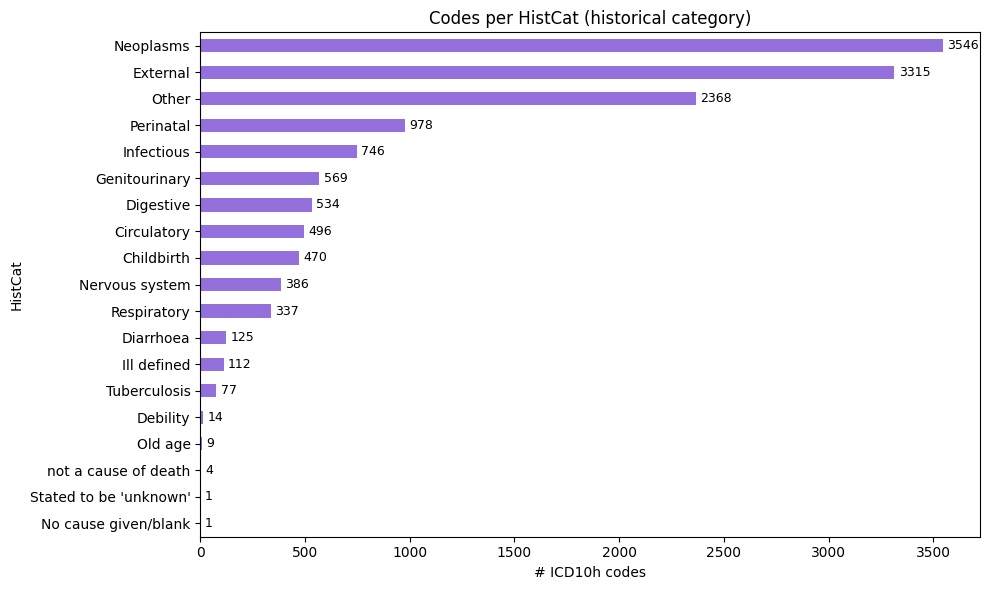


HistCat → Chapter mapping:
  Childbirth                     (  470 codes) → chapters: F, O
  Circulatory                    (  496 codes) → chapters: I, R
  Debility                       (   14 codes) → chapters: R
  Diarrhoea                      (  125 codes) → chapters: A, K
  Digestive                      (  534 codes) → chapters: K, R
  External                       (3,315 codes) → chapters: R, S, T, V, W, X, Y, Z
  Genitourinary                  (  569 codes) → chapters: N, R
  Ill defined                    (  112 codes) → chapters: R
  Infectious                     (  746 codes) → chapters: A, B
  Neoplasms                      (3,546 codes) → chapters: C, D
  Nervous system                 (  386 codes) → chapters: G, I, R
  No cause given/blank           (    1 codes) → chapters: R
  Old age                        (    9 codes) → chapters: R
  Other                          (2,368 codes) → chapters: D, E, F, H, L, M, R, T
  Perinatal                      (  978 codes) → 

In [9]:
histcat_counts = df["HistCat"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
histcat_counts.plot.barh(ax=ax, color="mediumpurple")
ax.set_xlabel("# ICD10h codes")
ax.set_title("Codes per HistCat (historical category)")
for i, v in enumerate(histcat_counts.values):
    ax.text(v + 20, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

# How HistCat maps to chapters
print("\nHistCat → Chapter mapping:")
for hc in sorted(df["HistCat"].unique()):
    chapters = sorted(df.loc[df["HistCat"] == hc, "chapter"].unique())
    n = len(df[df["HistCat"] == hc])
    print(f"  {hc:<30s} ({n:>5,} codes) → chapters: {', '.join(chapters)}")

## 4. Sunburst / treemap of the full hierarchy

Interactive visualization showing all 4 levels: Chapter → Block → Category → Leaf count.

In [5]:
import plotly.express as px

# Build a summary dataframe: one row per category with leaf count
tree_df = (
    df.groupby(["chapter", "block", "icd10_2levelCATEGORY"])
    .agg(n_codes=("leaf", "nunique"))
    .reset_index()
)

fig = px.sunburst(
    tree_df,
    path=["chapter", "block", "icd10_2levelCATEGORY"],
    values="n_codes",
    title="ICD10h Hierarchy — Sunburst (Chapter → Block → 2-level Category)",
    width=900,
    height=900,
)
fig.show()

In [6]:
fig2 = px.treemap(
    tree_df,
    path=["chapter", "block", "icd10_2levelCATEGORY"],
    values="n_codes",
    title="ICD10h Hierarchy — Treemap (Chapter → Block → 2-level Category)",
    width=1200,
    height=800,
)
fig2.show()

## 5. Problem nodes: where branching exceeds 25

These are the nodes where we'll need two-stage grouping in the tree search.

In [7]:
THRESHOLD = 25

print("=== Chapters with > 25 blocks ===")
problem_chapters = blocks_per_chapter[blocks_per_chapter > THRESHOLD]
for ch, n in problem_chapters.items():
    print(f"  Chapter {ch}: {n} blocks")

print(f"\n=== Blocks with > 25 categories: {(cats_per_block > THRESHOLD).sum()} / {len(cats_per_block)} ===")
problem_blocks = cats_per_block[cats_per_block > THRESHOLD].sort_values(ascending=False)
if len(problem_blocks) > 0:
    for blk, n in problem_blocks.head(15).items():
        desc = df.loc[df["block"] == blk, "icd10_2levelCATEGORY"].iloc[0]
        print(f"  {blk} ({desc}): {n} categories")

print(f"\n=== Categories with > 25 leaves: {(leaves_per_cat > THRESHOLD).sum()} / {len(leaves_per_cat)} ===")
problem_cats = leaves_per_cat[leaves_per_cat > THRESHOLD].sort_values(ascending=False)
if len(problem_cats) > 0:
    for cat, n in problem_cats.head(15).items():
        desc = df.loc[df["category"] == cat, "ICD10h_DESCRIPTION"].iloc[0]
        print(f"  {cat} ({desc}): {n} leaves")

=== Chapters with > 25 blocks ===
  Chapter A: 85 blocks
  Chapter B: 86 blocks
  Chapter C: 89 blocks
  Chapter D: 82 blocks
  Chapter E: 73 blocks
  Chapter F: 78 blocks
  Chapter G: 68 blocks
  Chapter H: 71 blocks
  Chapter I: 76 blocks
  Chapter J: 64 blocks
  Chapter K: 72 blocks
  Chapter L: 72 blocks
  Chapter M: 79 blocks
  Chapter N: 82 blocks
  Chapter O: 76 blocks
  Chapter P: 59 blocks
  Chapter Q: 87 blocks
  Chapter R: 91 blocks
  Chapter S: 100 blocks
  Chapter T: 95 blocks
  Chapter V: 97 blocks
  Chapter W: 88 blocks
  Chapter X: 97 blocks
  Chapter Y: 91 blocks
  Chapter Z: 84 blocks

=== Blocks with > 25 categories: 0 / 2042 ===

=== Categories with > 25 leaves: 0 / 10555 ===


## 6. Tree depth and shape summary

Compact overview of the tree that will be traversed by beam search.

In [8]:
print("ICD10h Tree Structure")
print("=====================")
print(f"")
print(f"  Root")
print(f"   └── {n_chapters} Chapters (A-Z letters)")
print(f"        └── {n_blocks:,} Blocks (3-char codes, e.g. A00)")
print(f"             └── {n_categories:,} Categories (5-char, e.g. A00.0)")
print(f"                  └── {n_leaves:,} Leaves (full ICD10h, e.g. A00.001)")
print(f"")
print(f"Max depth: 4 levels (Root → Chapter → Block → Category → Leaf)")
print(f"")
print(f"Branching factor summary:")
print(f"  Root → Chapter:   fixed {n_chapters}")
print(f"  Chapter → Block:  mean {blocks_per_chapter.mean():.0f}, max {blocks_per_chapter.max()}")
print(f"  Block → Category: mean {cats_per_block.mean():.1f}, max {cats_per_block.max()}")
print(f"  Category → Leaf:  mean {leaves_per_cat.mean():.1f}, max {leaves_per_cat.max()}")
print(f"")
print(f"Beam search calls per CoD (beam_width=3):")
print(f"  Depth 0 (root→chapter):     1 call  (25 options)")
print(f"  Depth 1 (chapter→block):    3 calls (variable options)")
print(f"  Depth 2 (block→category):   9 calls (usually ≤10 options)")
print(f"  Depth 3 (category→leaf):    27 calls (usually ≤5 options)")
print(f"  Total: ~40 LLM calls per CoD string (worst case)")
print(f"")
print(f"Nodes exceeding max_children=25:")
print(f"  Chapter level:  {(blocks_per_chapter > 25).sum()} / {n_chapters}")
print(f"  Block level:    {(cats_per_block > 25).sum()} / {n_blocks}")
print(f"  Category level: {(leaves_per_cat > 25).sum()} / {n_categories}")

ICD10h Tree Structure

  Root
   └── 25 Chapters (A-Z letters)
        └── 2,042 Blocks (3-char codes, e.g. A00)
             └── 10,555 Categories (5-char, e.g. A00.0)
                  └── 14,088 Leaves (full ICD10h, e.g. A00.001)

Max depth: 4 levels (Root → Chapter → Block → Category → Leaf)

Branching factor summary:
  Root → Chapter:   fixed 25
  Chapter → Block:  mean 82, max 100
  Block → Category: mean 5.2, max 10
  Category → Leaf:  mean 1.3, max 18

Beam search calls per CoD (beam_width=3):
  Depth 0 (root→chapter):     1 call  (25 options)
  Depth 1 (chapter→block):    3 calls (variable options)
  Depth 2 (block→category):   9 calls (usually ≤10 options)
  Depth 3 (category→leaf):    27 calls (usually ≤5 options)
  Total: ~40 LLM calls per CoD string (worst case)

Nodes exceeding max_children=25:
  Chapter level:  25 / 25
  Block level:    0 / 2042
  Category level: 0 / 10555
